In [1]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import cmocean.cm as cmo
import numpy as np


In [8]:
d_bath=xr.open_dataset('/Users/estel/Library/CloudStorage/Dropbox/SOCCO-UCT/Datasets/supplementary/bathymetry/gebco_SA.nc').sel(lat=slice(-4,4))#,lon=slice(np.nanmin(lon), np.nanmax(lon)))
wam_stations = pd.read_csv('/Users/estel/Library/CloudStorage/Dropbox/SOCCO-UCT/Datasets/supplementary/model_WAM_benguela/CoordinatesExport-20260206T0145.csv')

In [9]:
station_number = wam_stations.iloc[:, 0]

# Latitude
lat_deg = wam_stations.iloc[:, 1]
lat_dec = wam_stations.iloc[:, 2]
lat_dir = wam_stations.iloc[:, 3]   # 'N' or 'S'

lat_ = lat_deg + (lat_dec / 100)

# Apply sign: South = negative
latitude_stations = np.where(lat_dir == 'S', -lat_, lat_)

# Longitude
lon_deg = wam_stations.iloc[:, 4]
lon_dec = wam_stations.iloc[:, 5]
lon_dir = wam_stations.iloc[:, 6]   # 'E' or 'W'

lon_ = lon_deg + (lon_dec / 100)

# Apply sign: West = negative
longitude_station = np.where(lon_dir == 'W', -lon_, lon_)

In [10]:
# 2017-2022 daily - surface
ds_sst=xr.open_dataset('/Users/estel/Library/CloudStorage/Dropbox/SOCCO-UCT/Datasets/supplementary/model_WAM_equator/CESM_SST_daily_EQATL.nc')
ds_ssh=xr.open_dataset('/Users/estel/Library/CloudStorage/Dropbox/SOCCO-UCT/Datasets/supplementary/model_WAM_equator/CESM_SSH_daily_EQATL.nc')
ds_u=xr.open_dataset('/Users/estel/Library/CloudStorage/Dropbox/SOCCO-UCT/Datasets/supplementary/model_WAM_equator/CESM_UVEL_daily_EQATL.nc')
ds_v=xr.open_dataset('/Users/estel/Library/CloudStorage/Dropbox/SOCCO-UCT/Datasets/supplementary/model_WAM_equator/CESM_VVEL_daily_EQATL.nc')
ds_chl=xr.open_dataset('/Users/estel/Library/CloudStorage/Dropbox/SOCCO-UCT/Datasets/supplementary/model_WAM_equator/CESM_CHLSURF_daily_EQATL.nc')
ds_chl = ds_chl.rename({"__xarray_dataarray_variable__": "CHL"})
ds_co2=xr.open_dataset('/Users/estel/Library/CloudStorage/Dropbox/SOCCO-UCT/Datasets/supplementary/model_WAM_equator/CESM_FG_CO2_daily_EQATL.nc')


In [173]:
datasets = [ds_sst, ds_ssh, ds_u, ds_v, ds_chl, ds_co2]
variables = ['SST', 'SSH_2', 'U1_1', 'V1_1', 'CHL', 'FG_CO2_2']
cmaps = ['cmo.thermal', 'cmo.balance', 'cmo.balance', 'cmo.balance', 'cmo.algae', 'cmo.balance']

In [170]:
lon = ds_sst.TLONG.max("nlat").values
lat = ds_sst.TLAT.max("nlon").values
lon_new = ((lon + 180) % 360) - 180

datetime = pd.to_datetime([str(t) for t in ds_sst.time.values])

for ds in datasets:
    ds['datetime']=('time', datetime)

# Plot maps mean and std

In [174]:
def plot_maps(i, month):
    ds=datasets[i].copy()
    variable=variables[i]
    df=ds.groupby('time.month')[month]

    plt.figure(figsize=(12,6), constrained_layout=True)
    plt.subplot(211)
    plt.title(str(month))
    plt.contour(d_bath.lon[::10], d_bath.lat[::10], d_bath.elevation[::10,::10], levels=[0], colors='k')

    plt_mean=df[variable].mean('time')
    vmin_ , vmax_ = np.nanpercentile(plt_mean, 2), np.nanpercentile(plt_mean, 98) 
    if i==1:
        maxabs_v=np.max([np.abs(vmin_), np.abs(vmax_)])
        vmin_, vmax_= -maxabs_v,maxabs_v
    if i==4:
        maxabs_v=np.max([np.abs(vmin_), np.abs(vmax_)])
        vmin_, vmax_= -maxabs_v,maxabs_v

    if i==2:
        maxabs_v=np.max([np.abs(vmin_), np.abs(vmax_)])
        vmin_, vmax_= -maxabs_v,maxabs_v
    if i==3:
        maxabs_v=np.max([np.abs(vmin_), np.abs(vmax_)])
        vmin_, vmax_= -maxabs_v,maxabs_v
    plt.pcolormesh(lon_new, lat, plt_mean, cmap=cmaps[i], shading="auto", vmin=vmin_, vmax=vmax_)

    plt.ylabel("Latitude")
    plt.colorbar(label='mean '+variable, extend='both')
    plt.axhline(0, c='gray', alpha=0.5)
    plt.scatter(longitude_station, latitude_stations, marker='s', c='silver', s=20)

    plt.scatter(-10,0, marker='x', c='w', s=200)
    plt.scatter(-23,0, marker='x', c='w', s=200)
    plt.scatter(0,0, marker='x', c='w', s=200)
    plt.xlim(-50,10)
    plt.ylim(-4,4)
    plt.xticks([])

    plt.subplot(212)
    plt.contour(d_bath.lon[::10], d_bath.lat[::10], d_bath.elevation[::10,::10], levels=[0], colors='k')

    plt_mean=df[variable].std('time')
    vmin_ , vmax_ = 0, np.nanpercentile(plt_mean, 98) 

    plt.pcolormesh(lon_new, lat, plt_mean, cmap=cmo.amp, vmin=vmin_, vmax=vmax_, shading="auto")


    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.colorbar(label="std "+variable, extend='both')
    plt.axhline(0, c='gray', alpha=0.5)
    plt.axhline(0, c='gray', alpha=0.5)
    plt.scatter(longitude_station, latitude_stations, marker='s', c='silver', s=20)
    plt.scatter(-10,0, marker='x', c='w', s=200)
    plt.scatter(-23,0, marker='x', c='w', s=200)
    plt.scatter(0,0, marker='x', c='w', s=200)
    plt.ylim(-4,4)
    plt.xlim(-50,10)

    return plt.show()


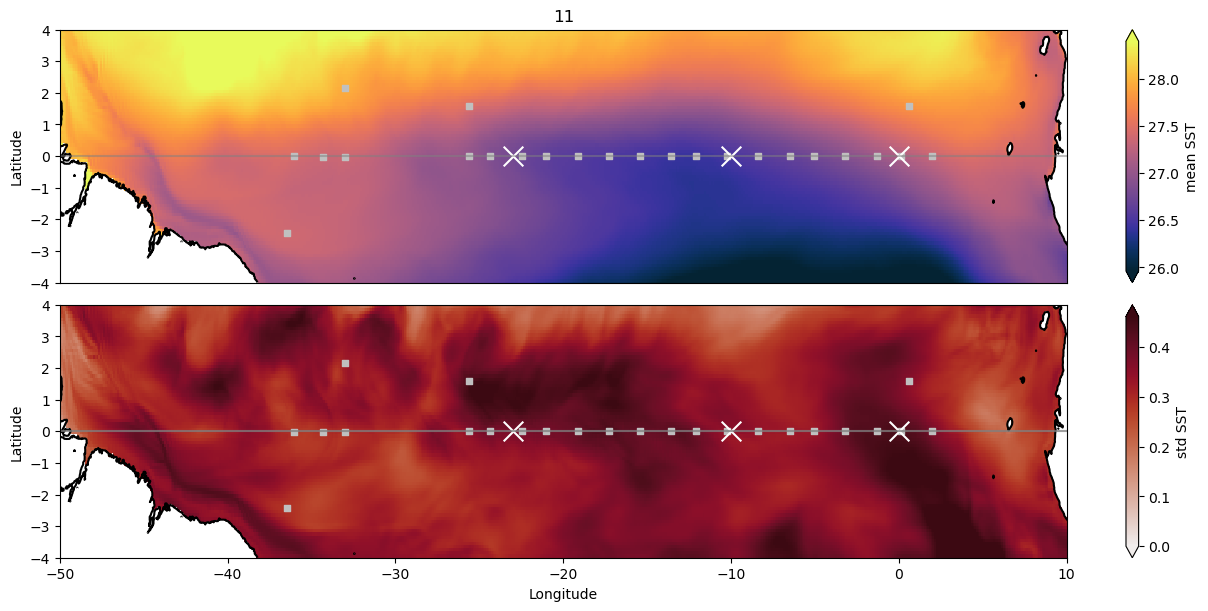

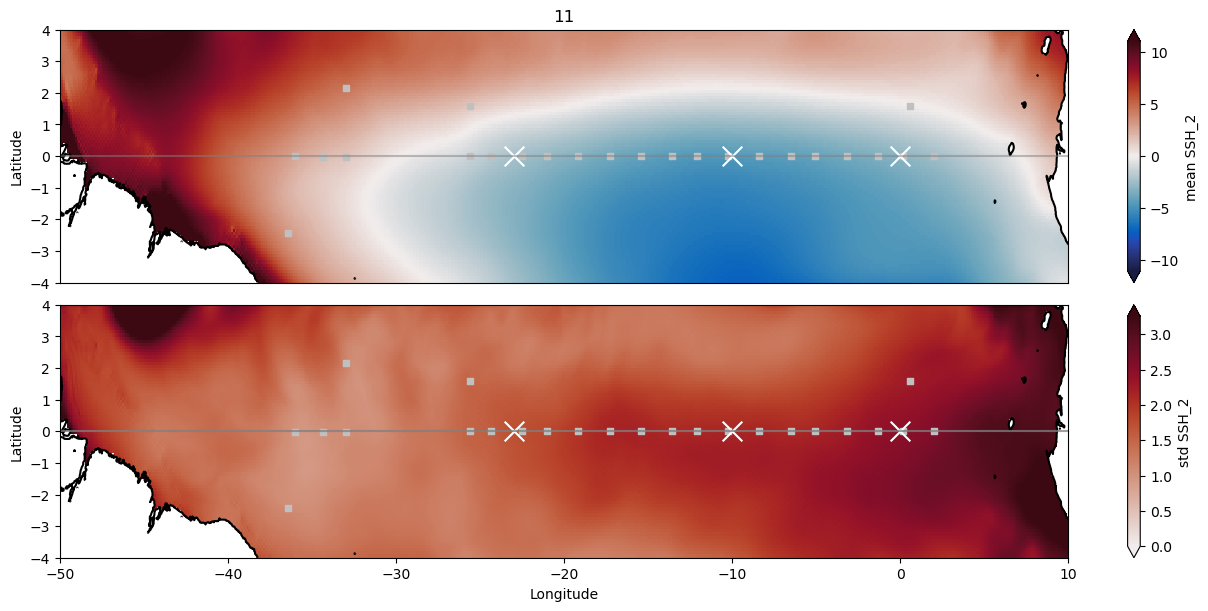

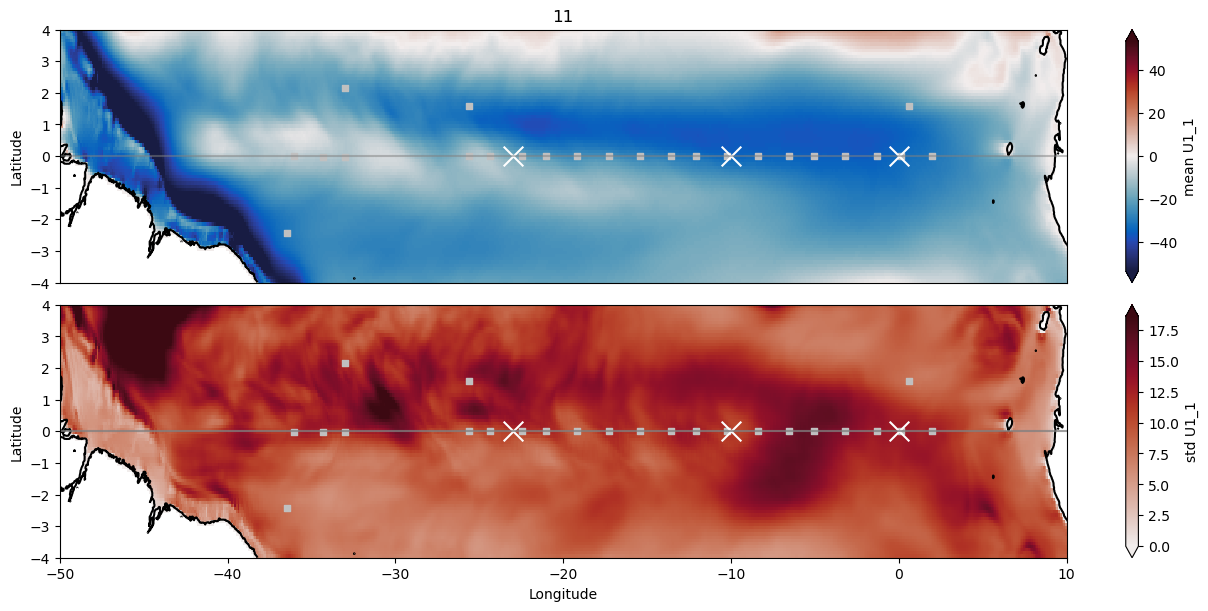

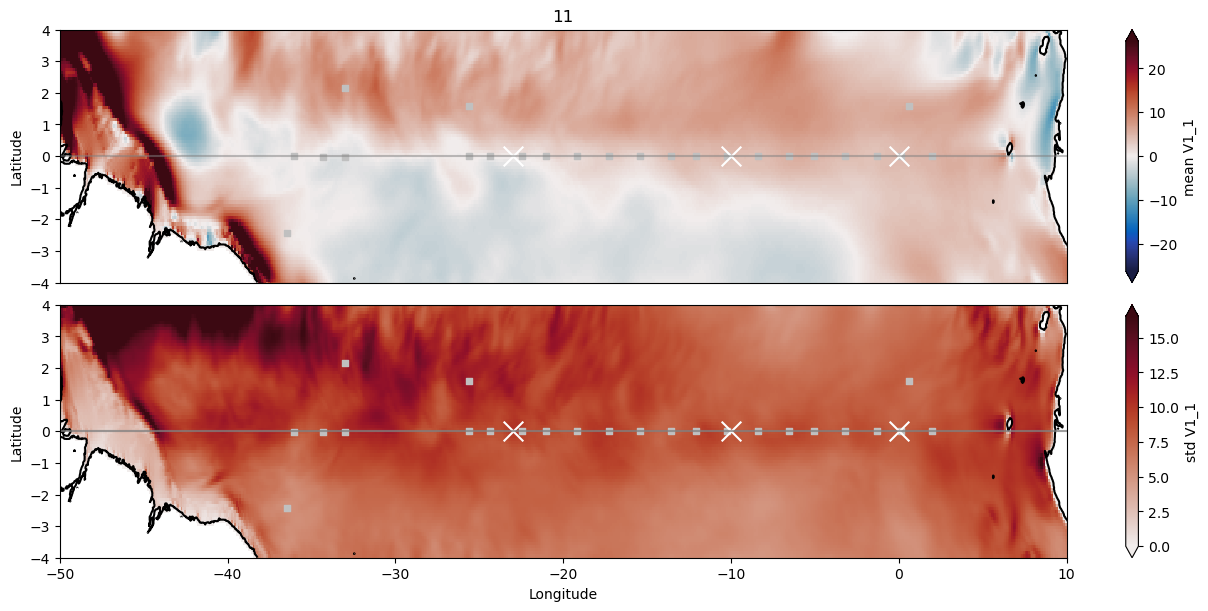

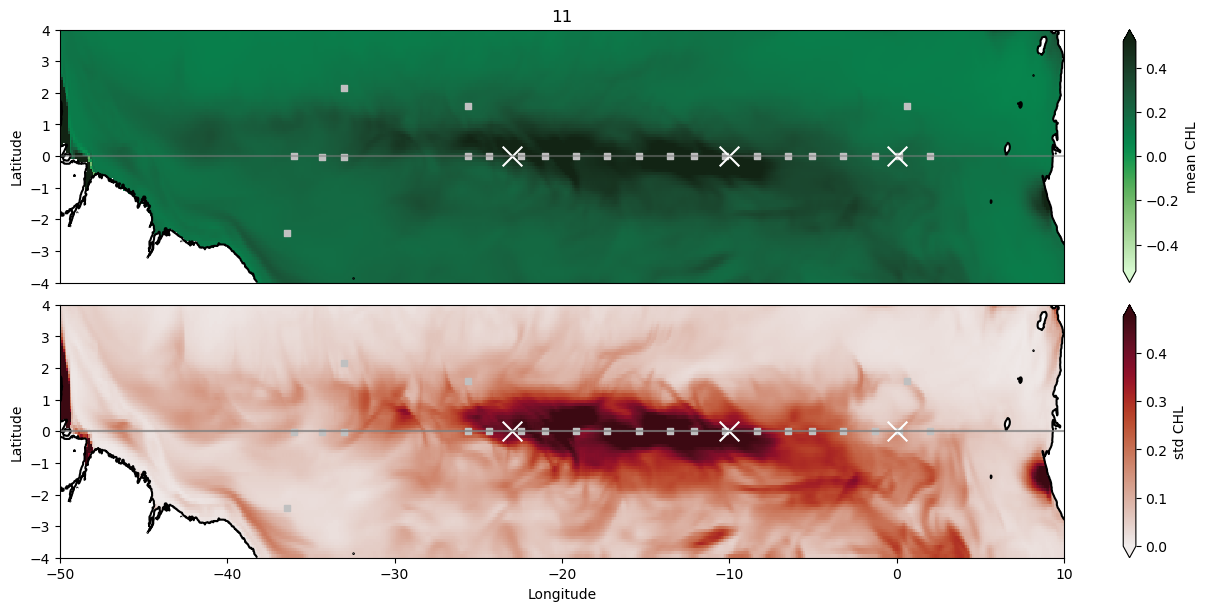

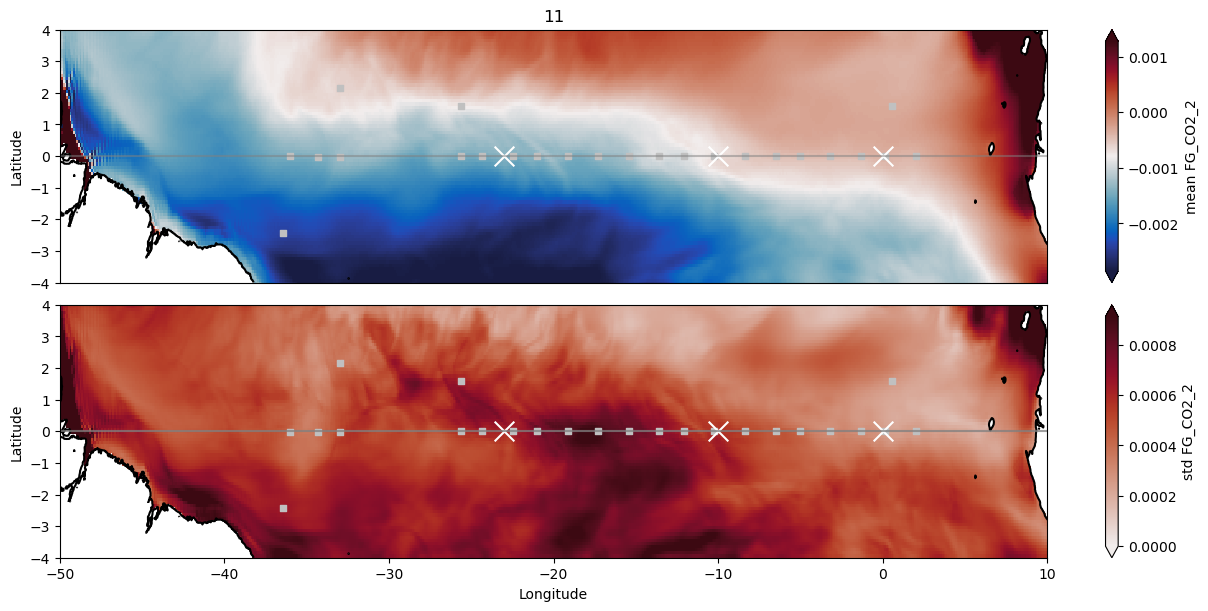

In [179]:
for i in range(0,6):
    plot_maps(i, 11)

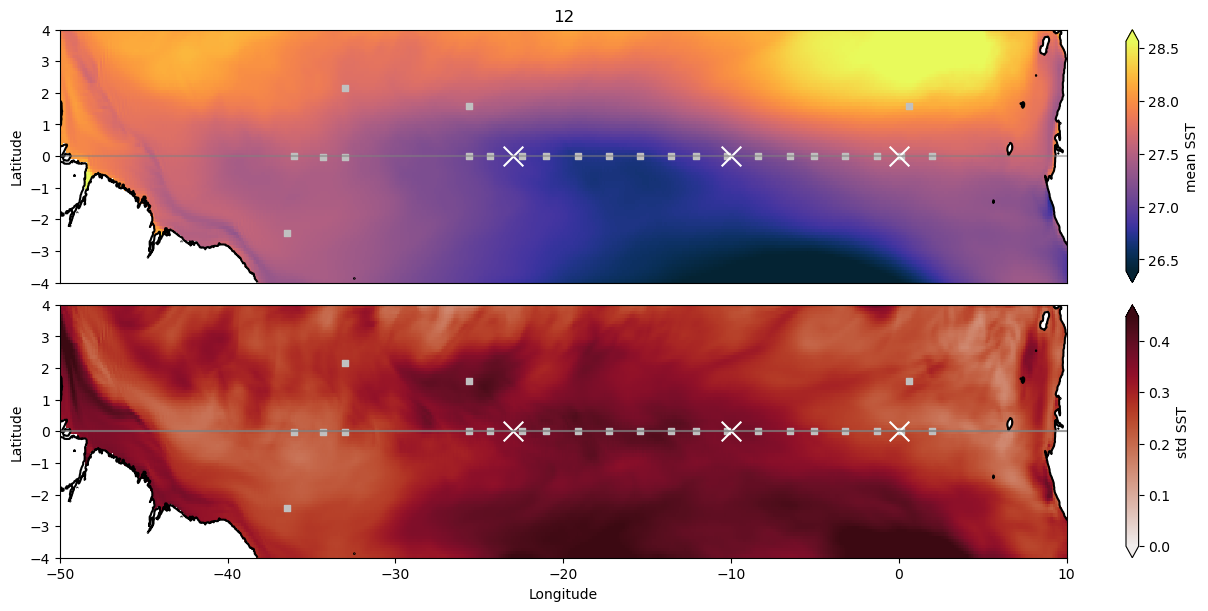

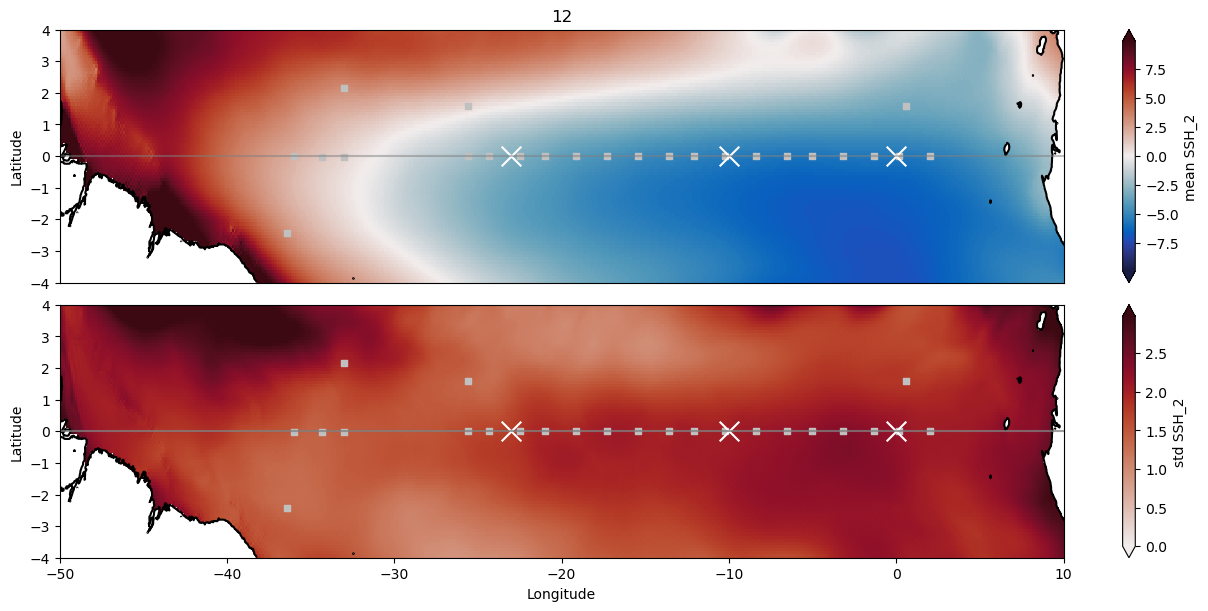

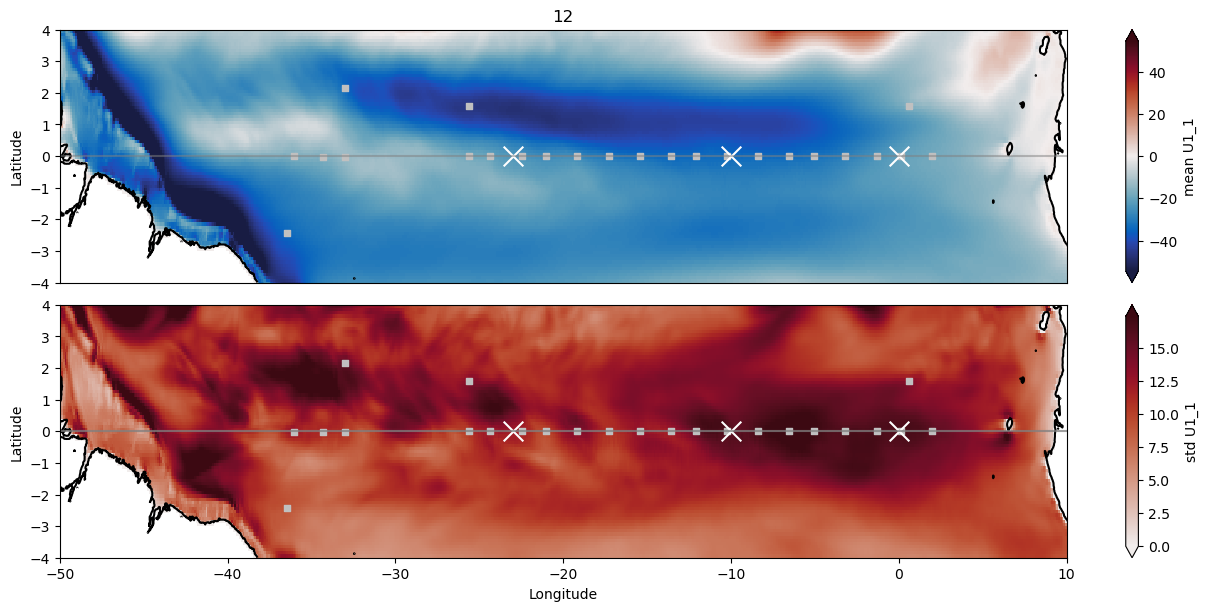

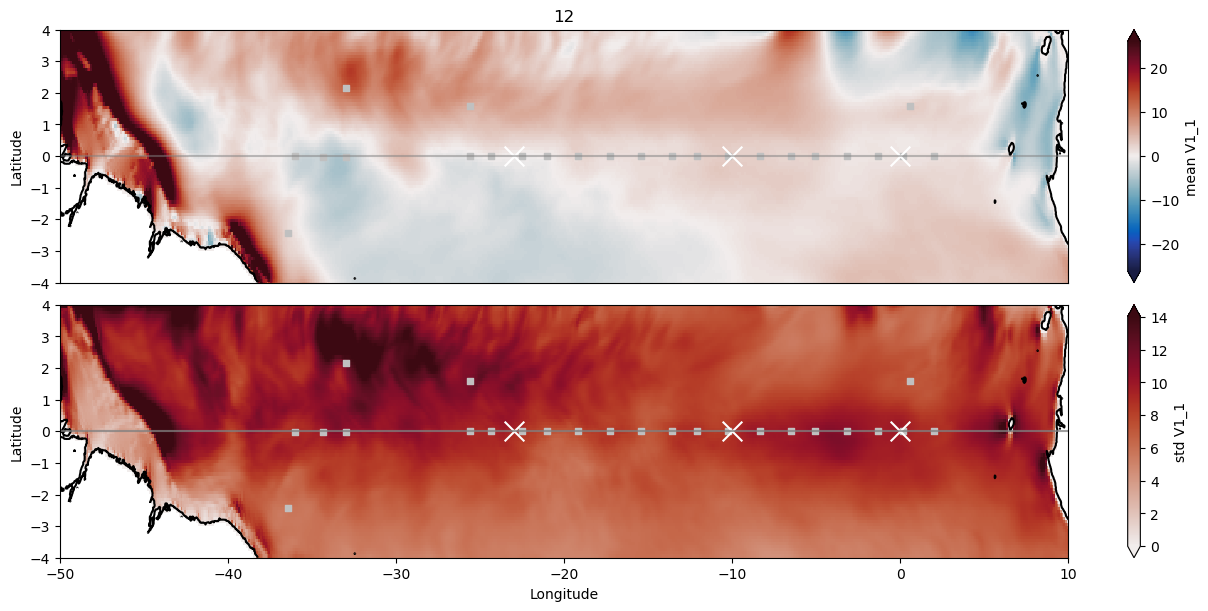

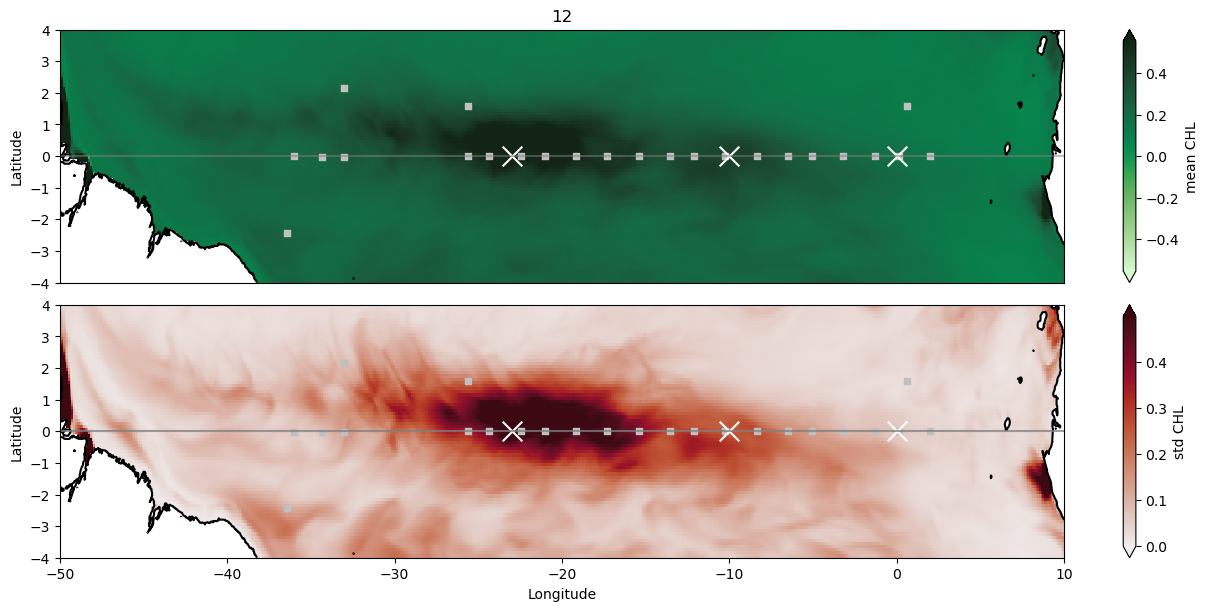

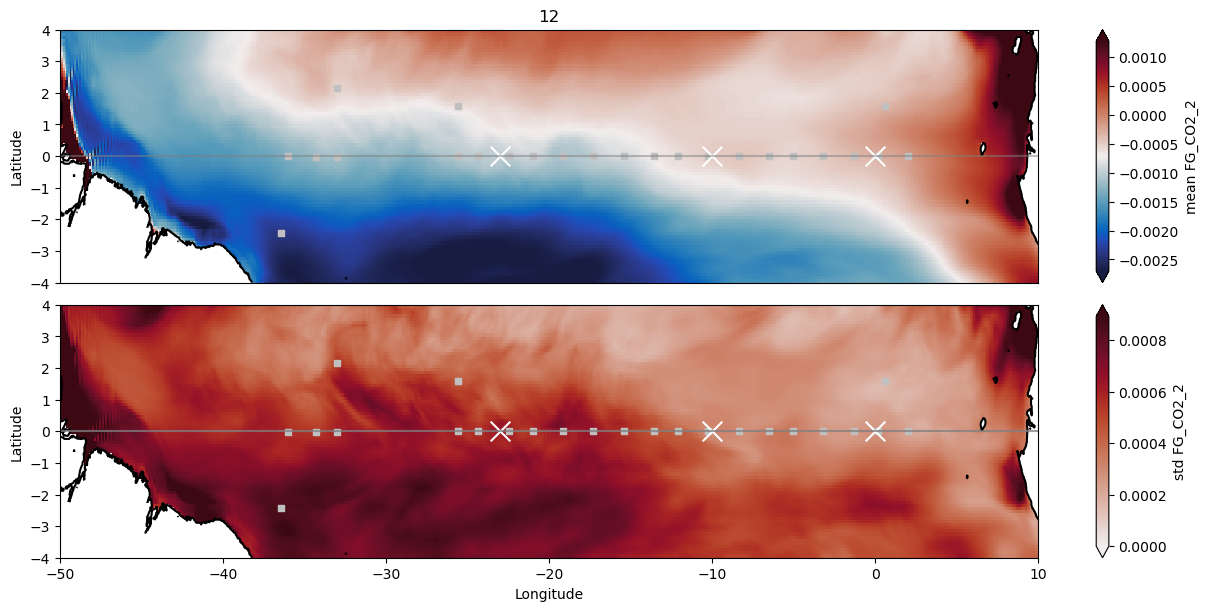

In [180]:
for i in range(0,6):
    plot_maps(i, 12)

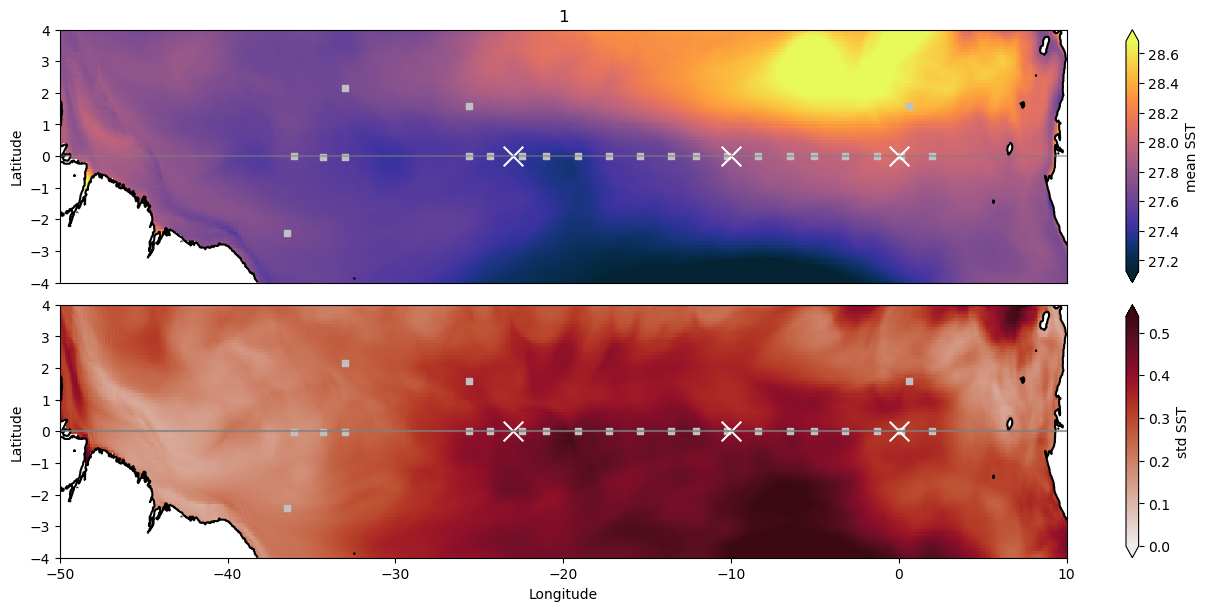

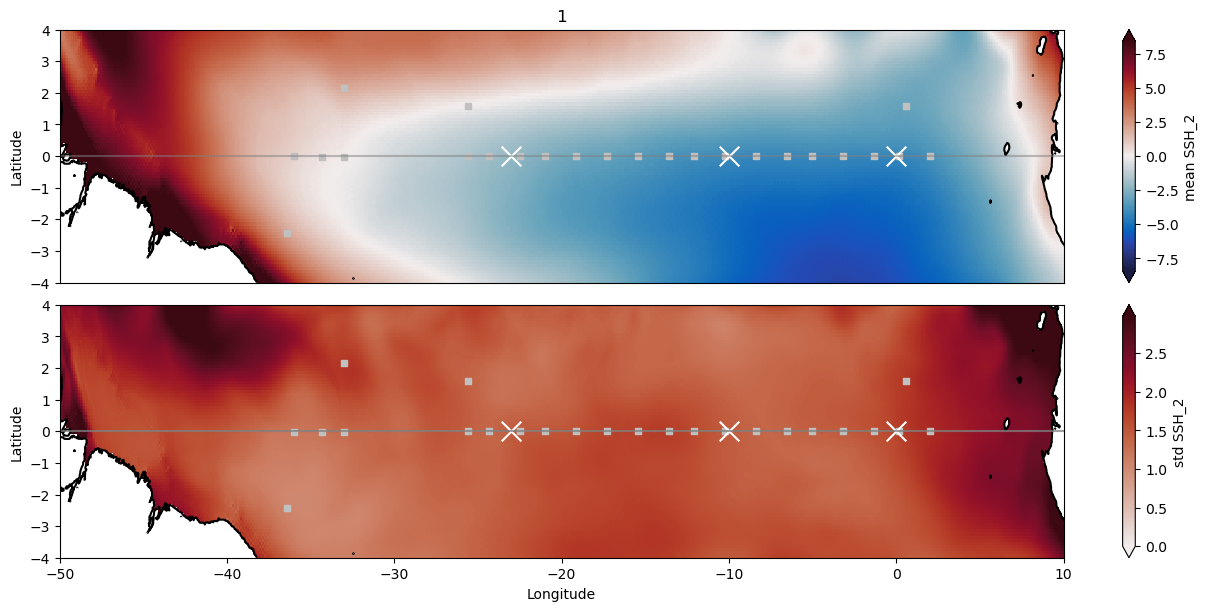

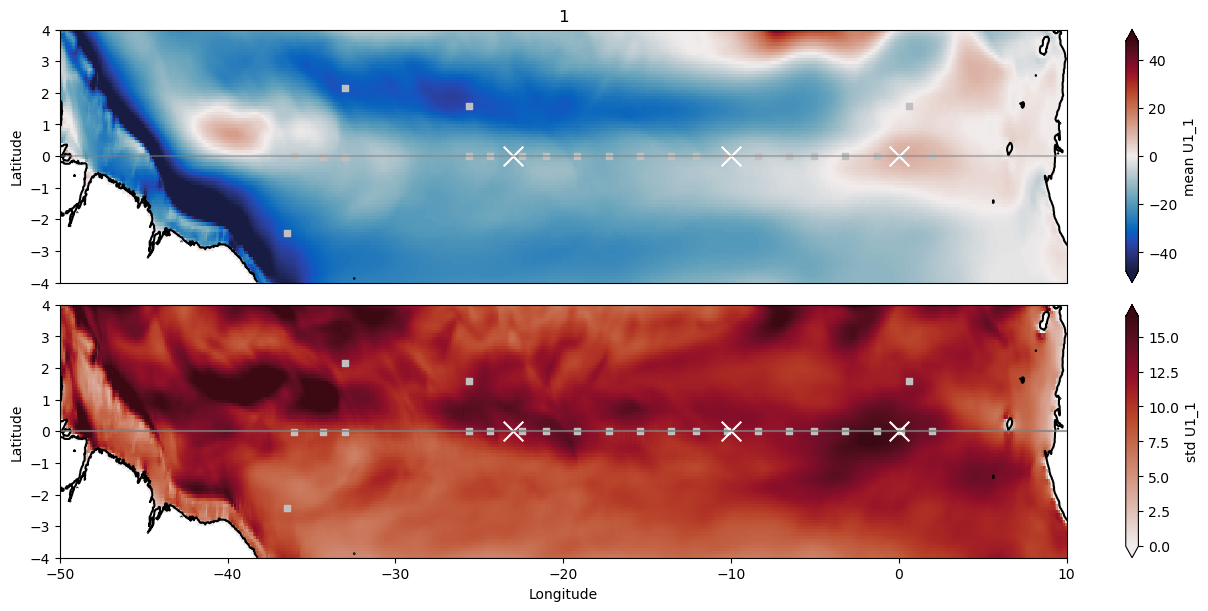

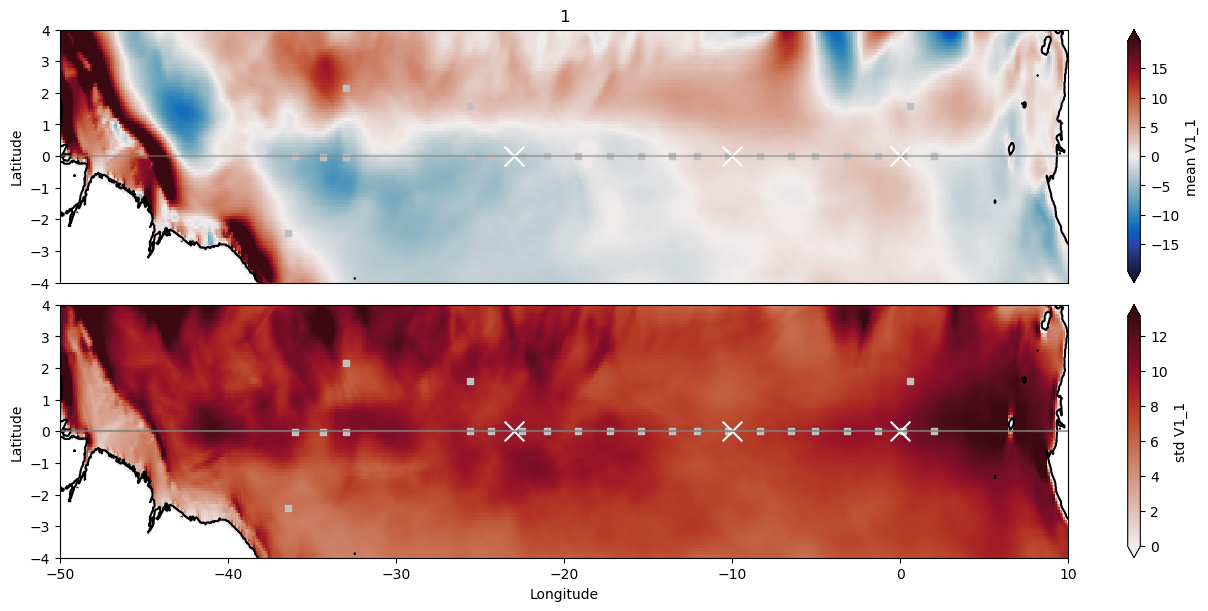

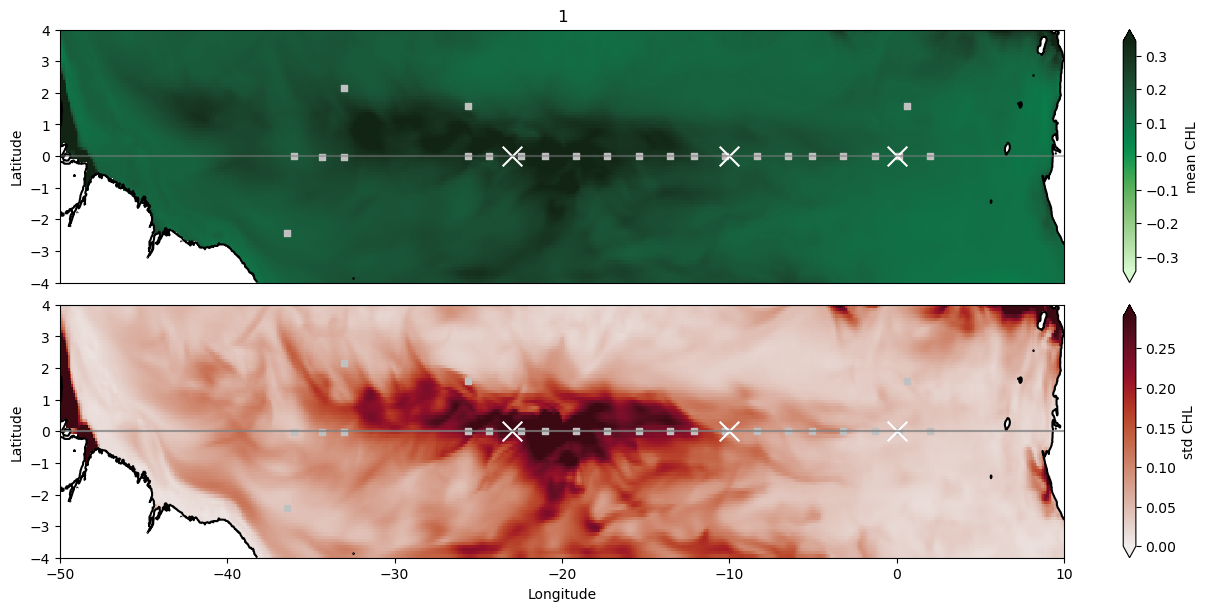

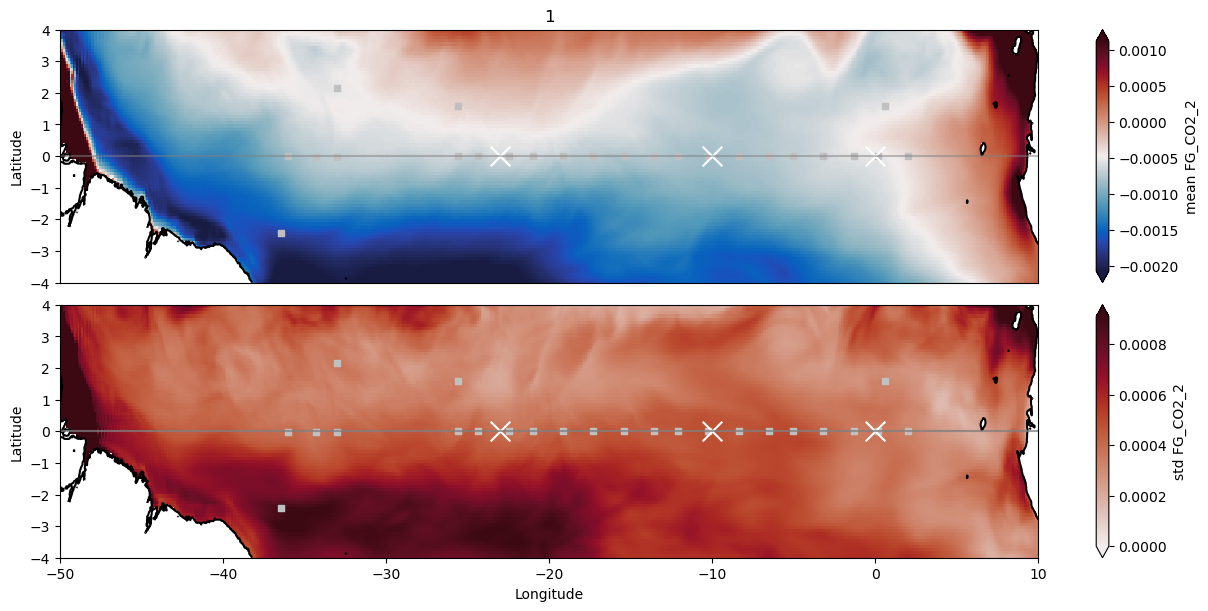

In [181]:
for i in range(0,6):
    plot_maps(i, 1)

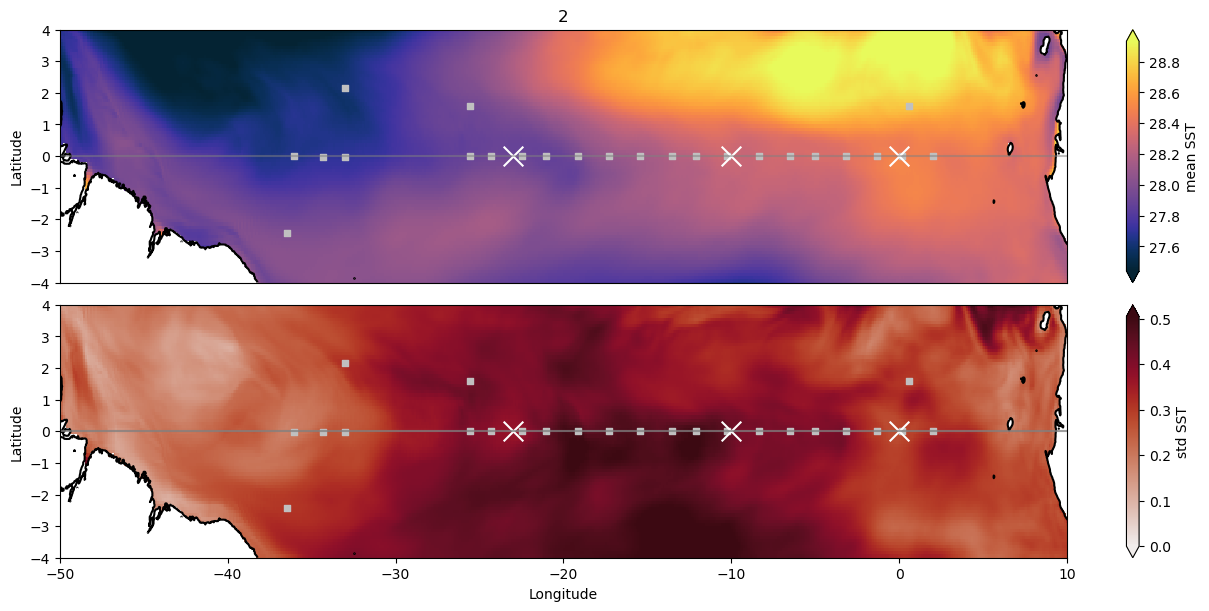

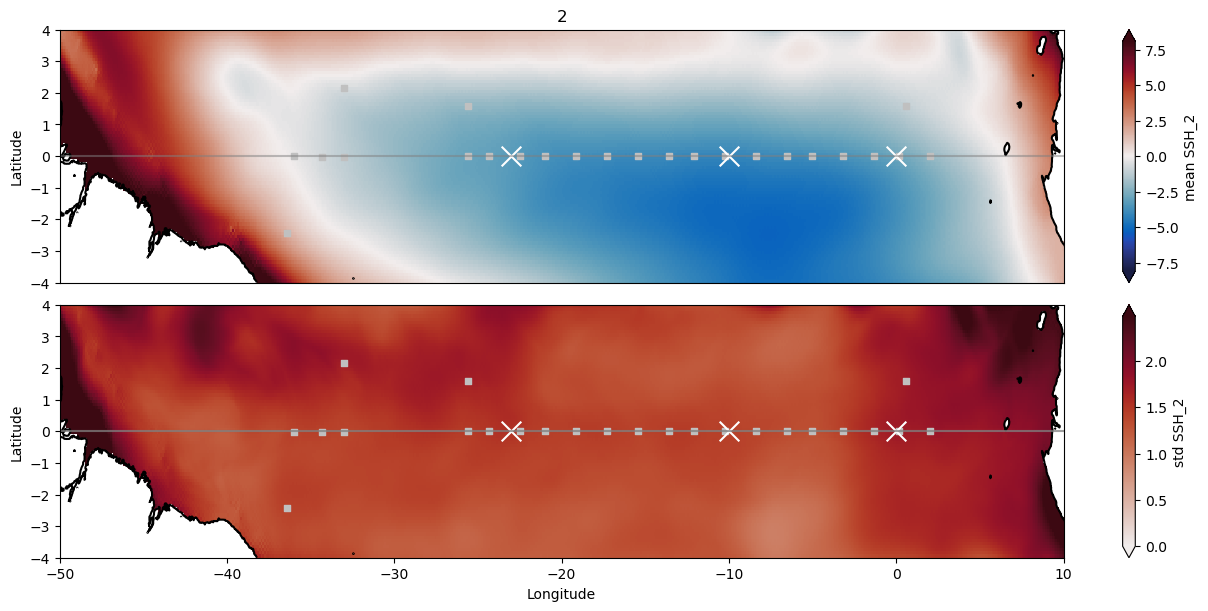

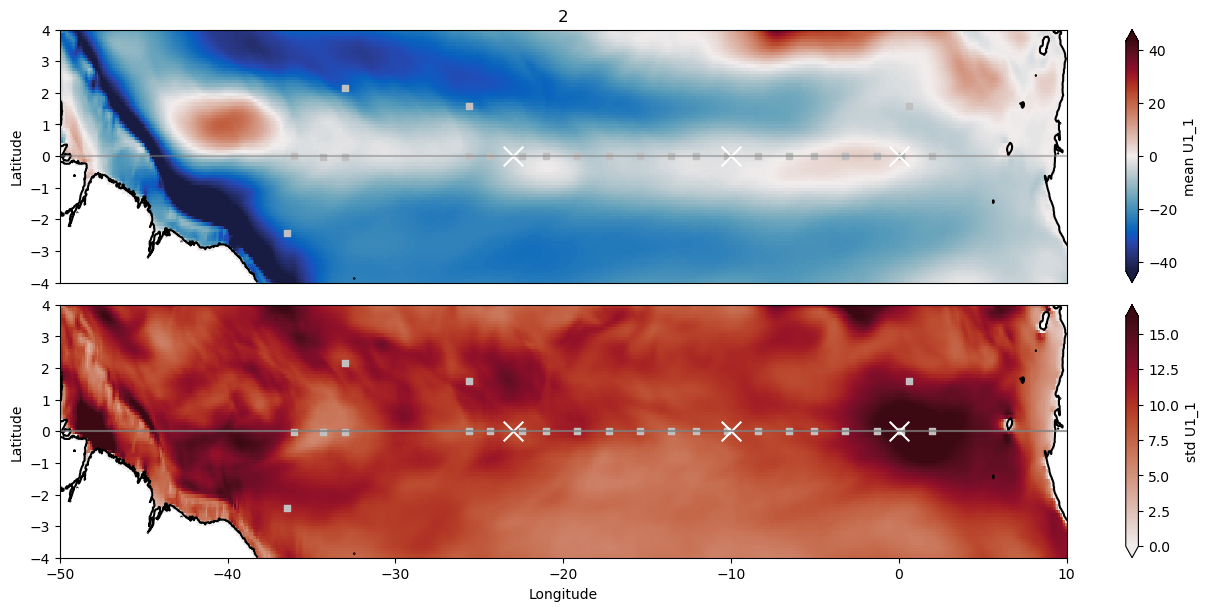

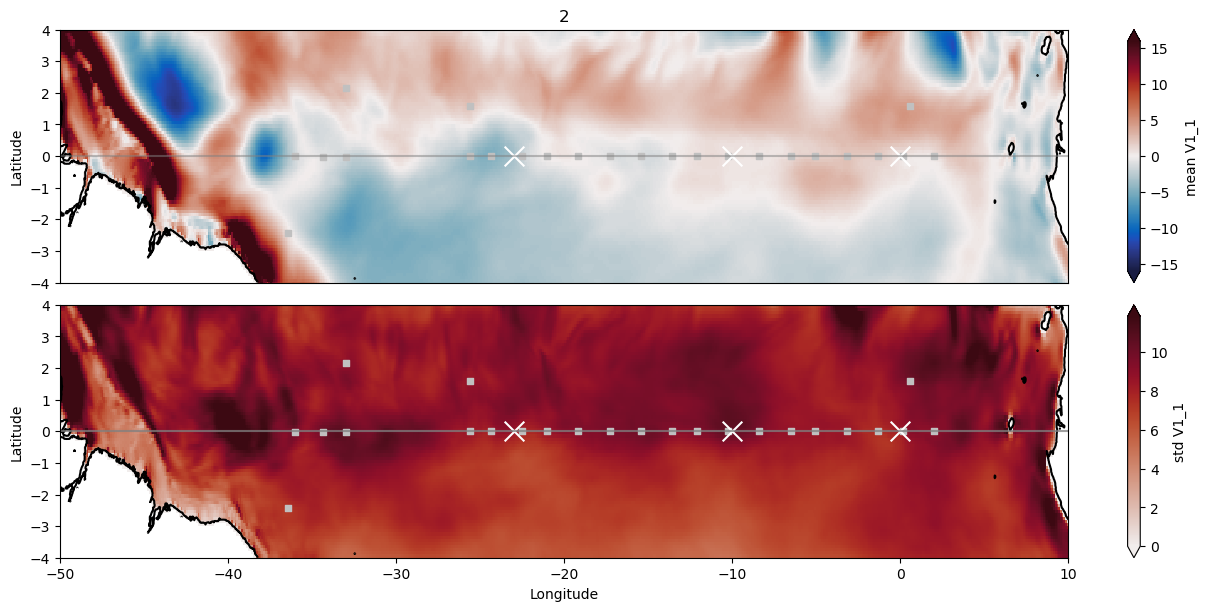

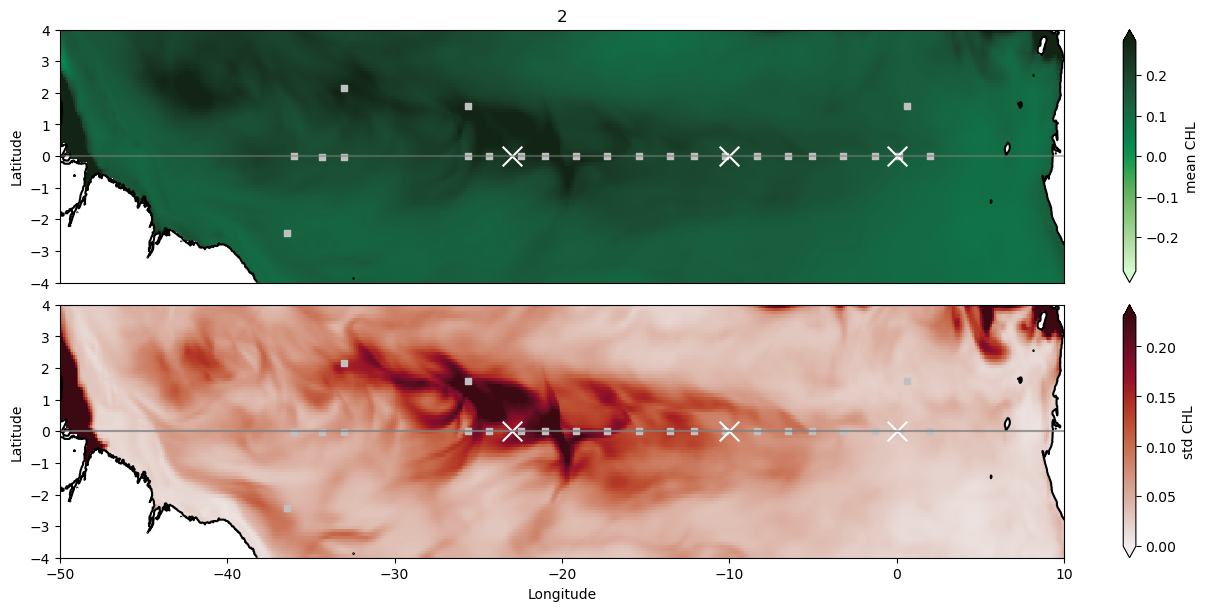

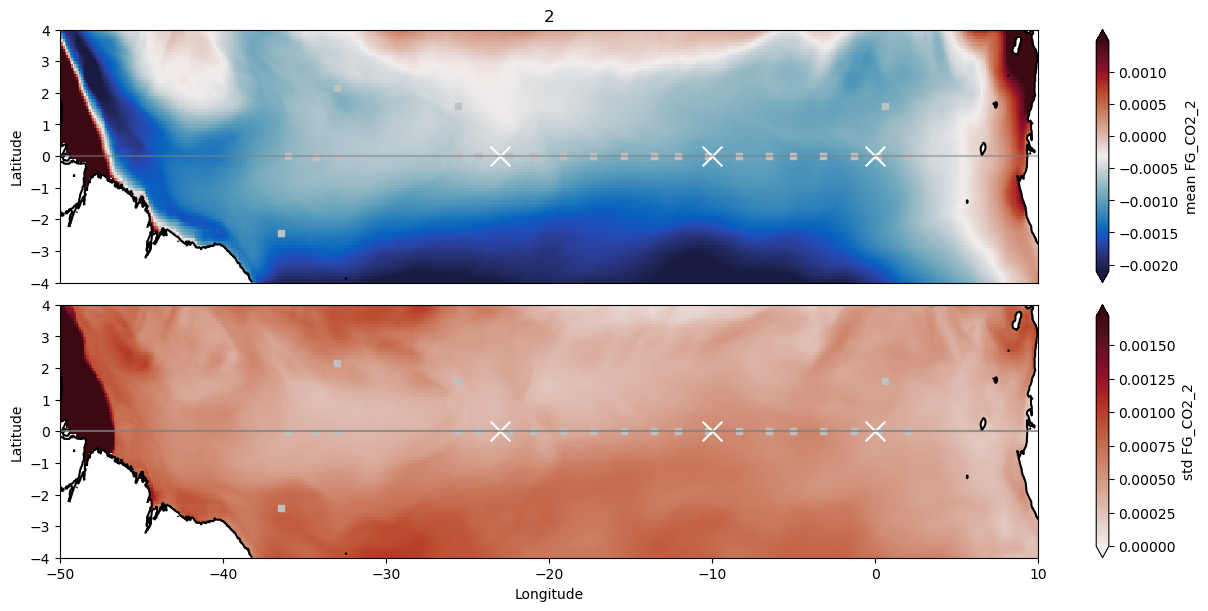

In [182]:
for i in range(0,6):
    plot_maps(i, 2)

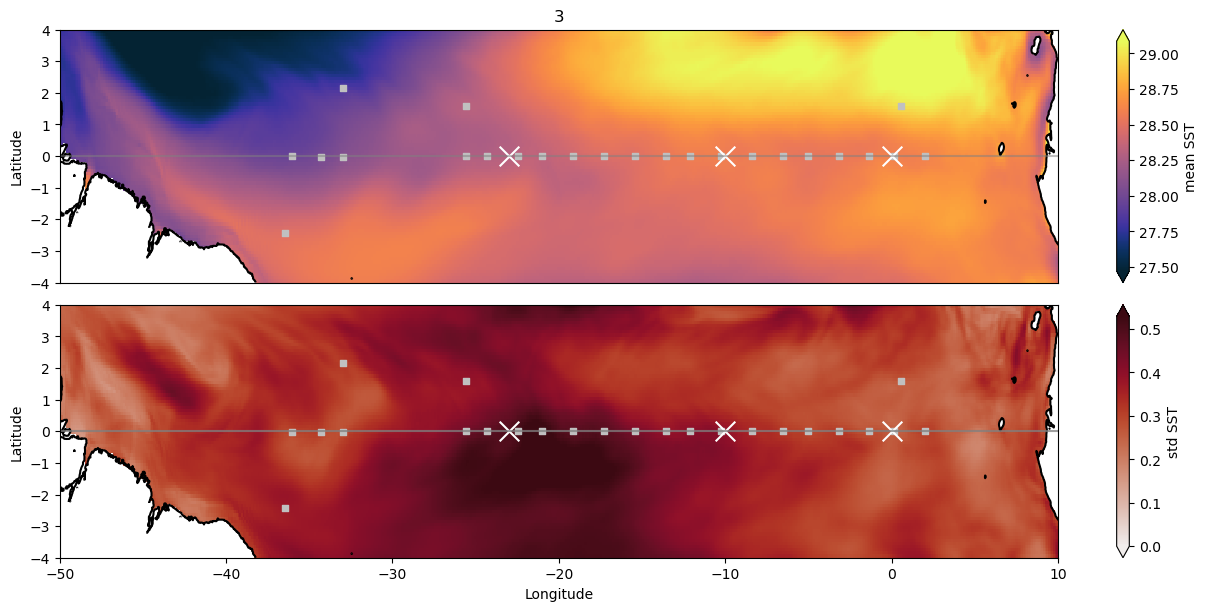

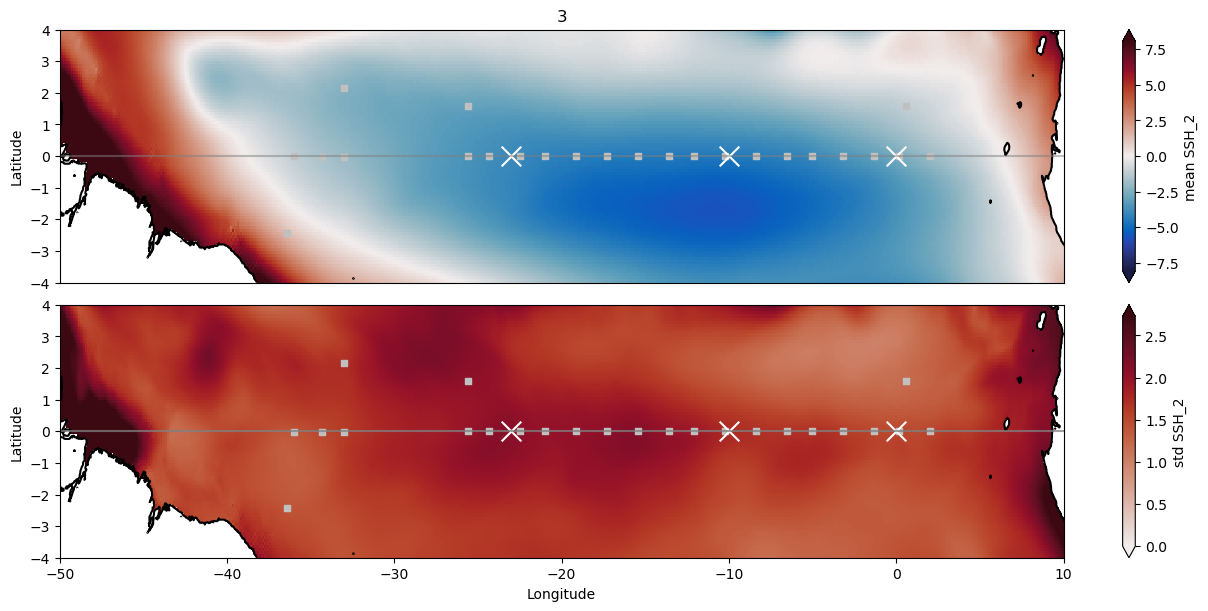

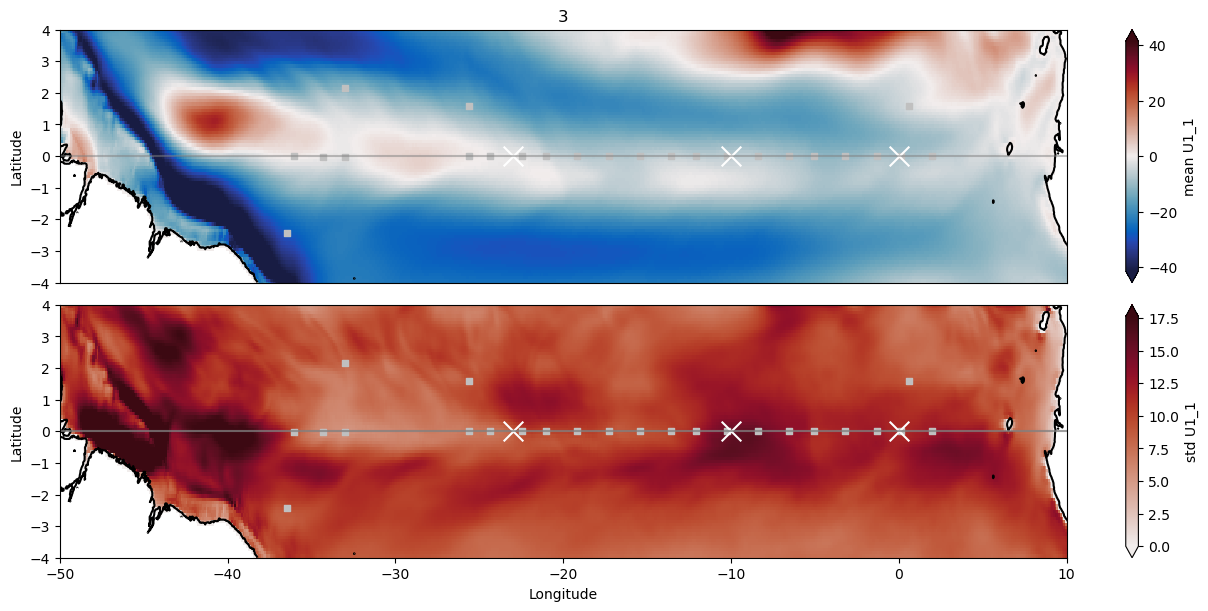

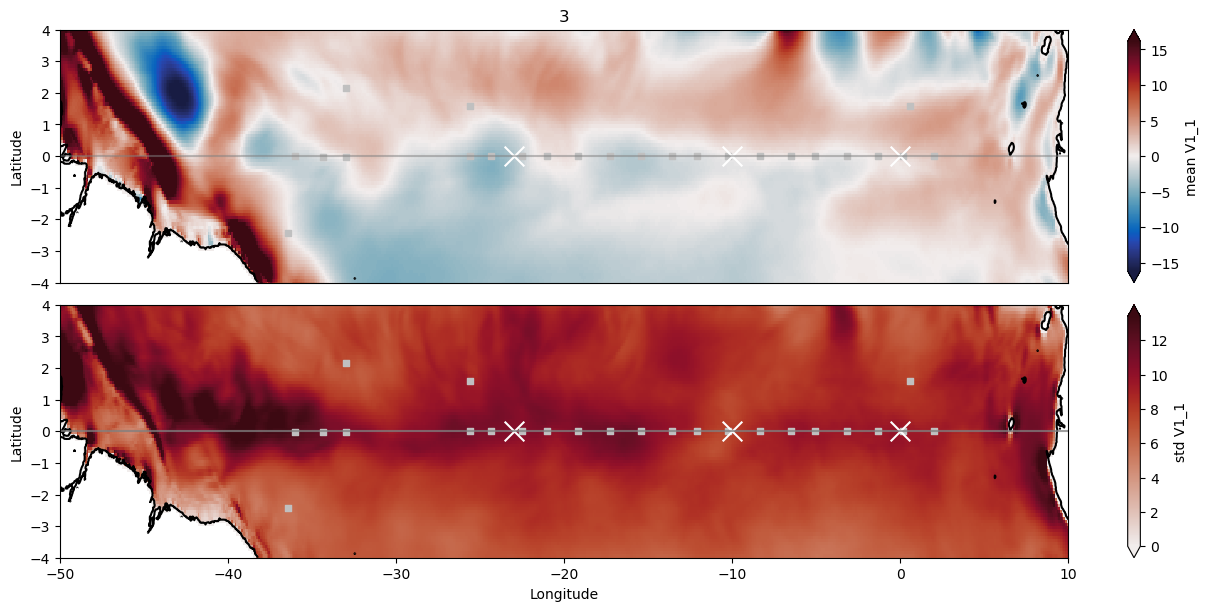

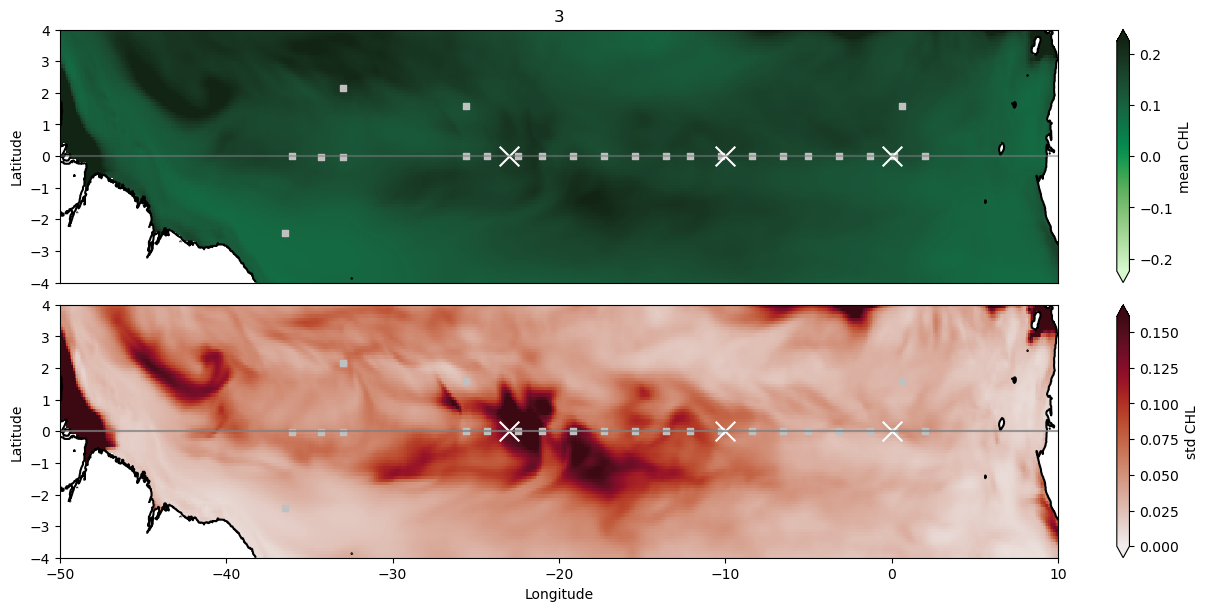

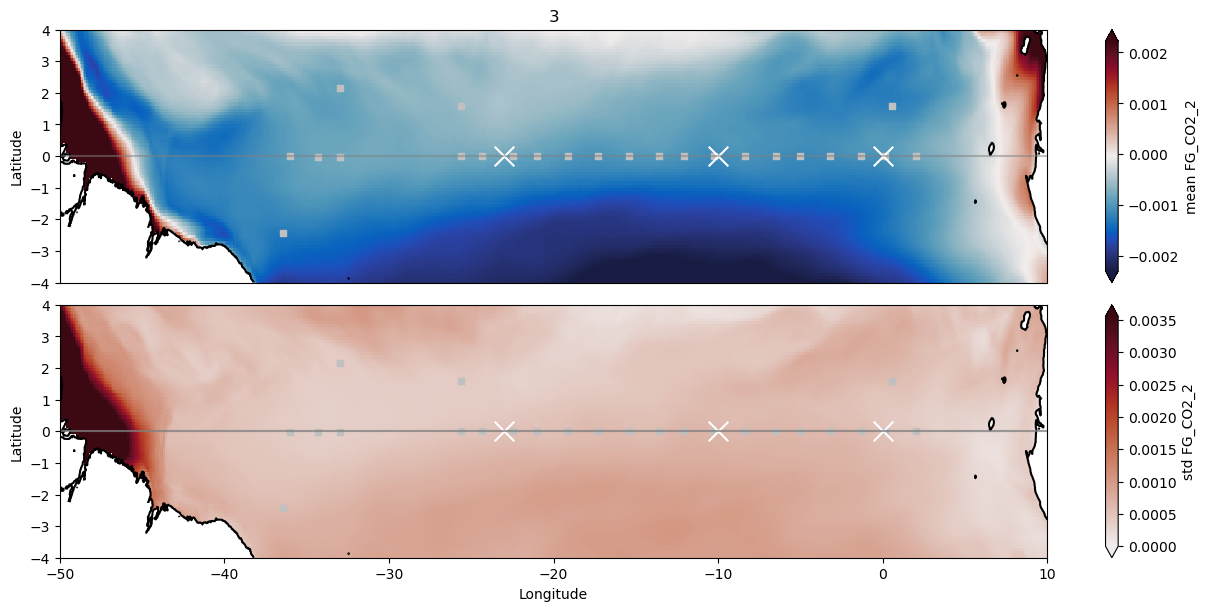

In [183]:
for i in range(0,6):
    plot_maps(i, 3)

# Plot Hovmollers

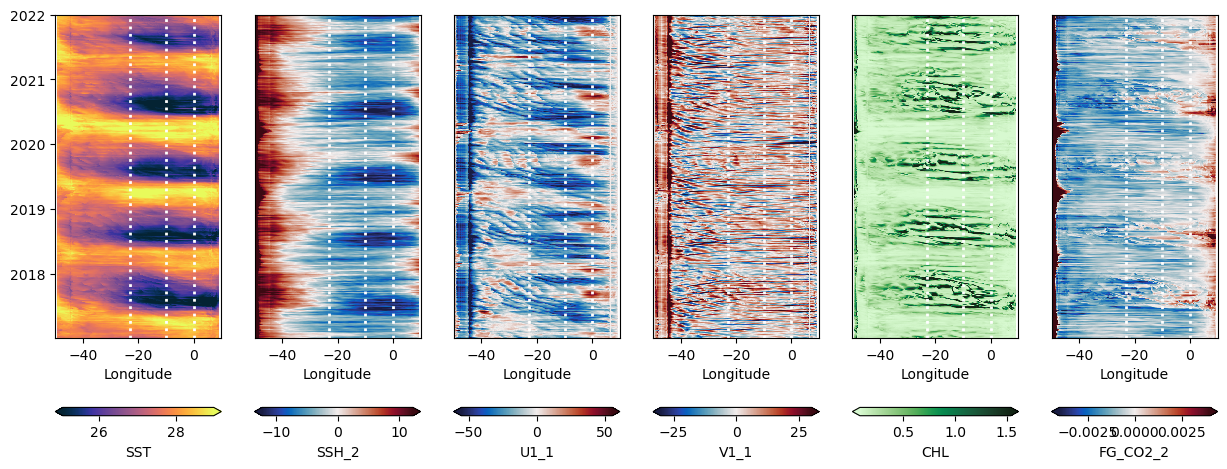

In [178]:
plt.figure(figsize=(15,6))

for i in range(0,6):
    plt.subplot(161+i)
    plt_mean=datasets[i].sel(nlat=41)[variables[i]]
    vmin_ , vmax_ = np.nanpercentile(plt_mean, 2), np.nanpercentile(plt_mean, 98) 
    if i==1:
        maxabs_v=np.max([np.abs(vmin_), np.abs(vmax_)])
        vmin_, vmax_= -maxabs_v,maxabs_v
    if i==5:
        maxabs_v=np.max([np.abs(vmin_), np.abs(vmax_)])
        vmin_, vmax_= -maxabs_v,maxabs_v
    if i==2:
        maxabs_v=np.max([np.abs(vmin_), np.abs(vmax_)])
        vmin_, vmax_= -maxabs_v,maxabs_v
    if i==3:
        maxabs_v=np.max([np.abs(vmin_), np.abs(vmax_)])
        vmin_, vmax_= -maxabs_v,maxabs_v
    plt.pcolormesh(lon_new, datetime, plt_mean, cmap=cmaps[i], vmin=vmin_, vmax=vmax_)
    plt.colorbar(label=variables[i], extend='both', orientation='horizontal')
    plt.xlim(-50,10)
    plt.xlabel('Longitude')

    plt.axvline(-10,0,  c='w', lw=2, ls=':')
    plt.axvline(-23,0,  c='w', lw=2, ls=':')
    plt.axvline(-0,0,  c='w', lw=2, ls=':')


    if i>0:
        plt.gca().set_yticks([])

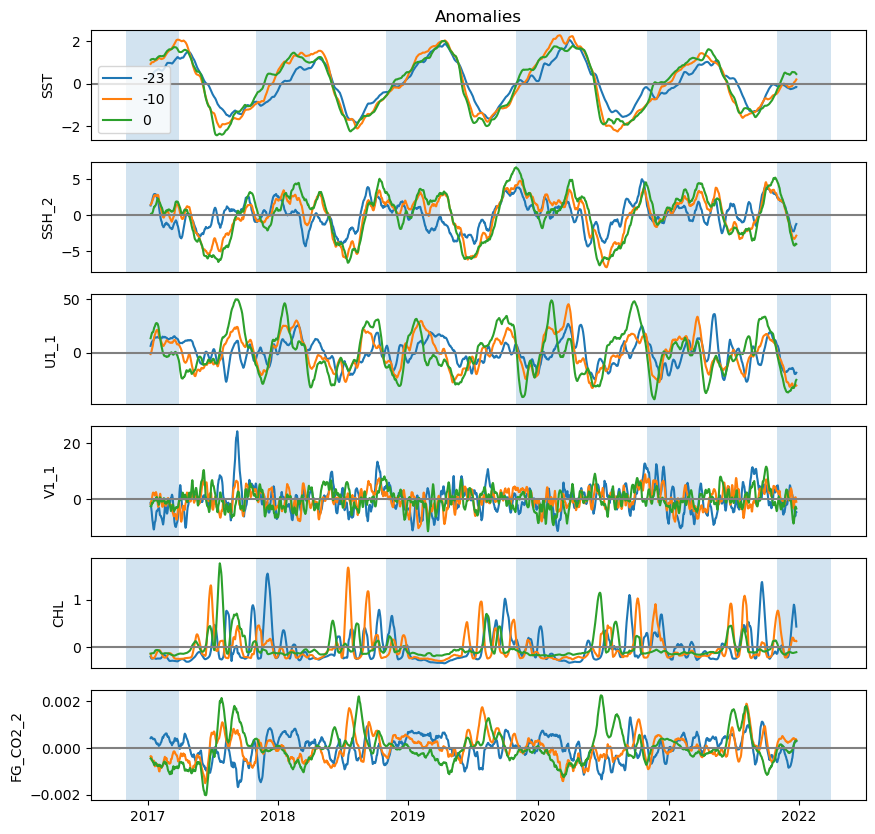

In [22]:
glider_ilon = 270, 400, 500 #lon_new[270], lon_new[400], lon_new[500]
plt.figure(figsize=(10,10))
for i in range(0,6):
    plt.subplot(611+i)
    if i ==0:
        plt.title('Anomalies')
    plt_mean=datasets[i].sel(nlat=41)[variables[i]].sel(nlon=glider_ilon[0])
    plt.plot(datetime, plt_mean.rolling(time=15,center=True).mean()-plt_mean.mean('time'), label=round((plt_mean.TLONG.values + 180) % 360) - 180)

    plt_mean=datasets[i].sel(nlat=41)[variables[i]].sel(nlon=glider_ilon[1])
    plt.plot(datetime, plt_mean.rolling(time=15,center=True).mean()-plt_mean.mean('time'), label=round((plt_mean.TLONG.values + 180) % 360) - 180)

    plt_mean=datasets[i].sel(nlat=41)[variables[i]].sel(nlon=glider_ilon[2])
    plt.plot(datetime, plt_mean.rolling(time=15,center=True).mean()-plt_mean.mean('time'), label=round((plt_mean.TLONG.values + 180) % 360) - 180)

    # Shade Nov to Mar for each year
    for year in range(2016, 2022):
        start = pd.Timestamp(year=year, month=11, day=1)
        end   = pd.Timestamp(year=year + 1, month=3, day=31)
        plt.axvspan(start, end, alpha=0.2)

    if i==0:
        plt.legend()
        

    plt.axhline(0, c='gray')

    if i!=5:
        plt.xticks([])
    plt.ylabel(variables[i])

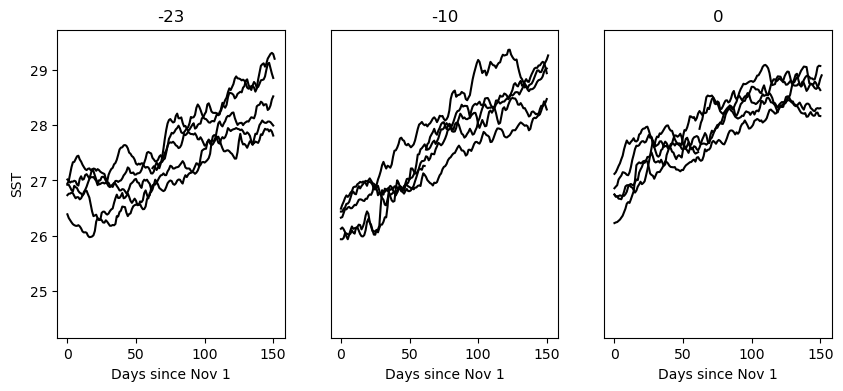

In [23]:

plt.figure(figsize=(10,4))

vmin_, vmax_=datasets[0][variables[0]].sel(nlat=41).min(), datasets[0][variables[0]].sel(nlat=41).max()
for ii in [0,1,2]:
    d_plot = datasets[0].sel(nlat=41).sel(nlon=glider_ilon[ii])
    # Make sure time is usable
    time = pd.to_datetime([str(t) for t in d_plot.time.values])
    d_plot["time"] = time
    
    plt.subplot(131+ii)
    plt.title(round(lon_new[glider_ilon[ii]]))
    for year in range(2016, 2022):
        start = f"{year}-11-01"
        end   = f"{year+1}-03-31"
        
        d_season = d_plot.sel(time=slice(start, end))
        # Continuous day count from Nov 1
        t = pd.to_datetime(d_season.time.values)
        season_day = (t - pd.Timestamp(f"{year}-11-01")).days
        
        plt.plot(season_day, d_season[variables[0]], c='k')

    if ii==0:
        plt.ylabel(variables[0])

    if ii>0:
        plt.yticks([])

    plt.xlabel("Days since Nov 1")
    plt.ylim(vmin_, vmax_)

0
1
2
3
4
5


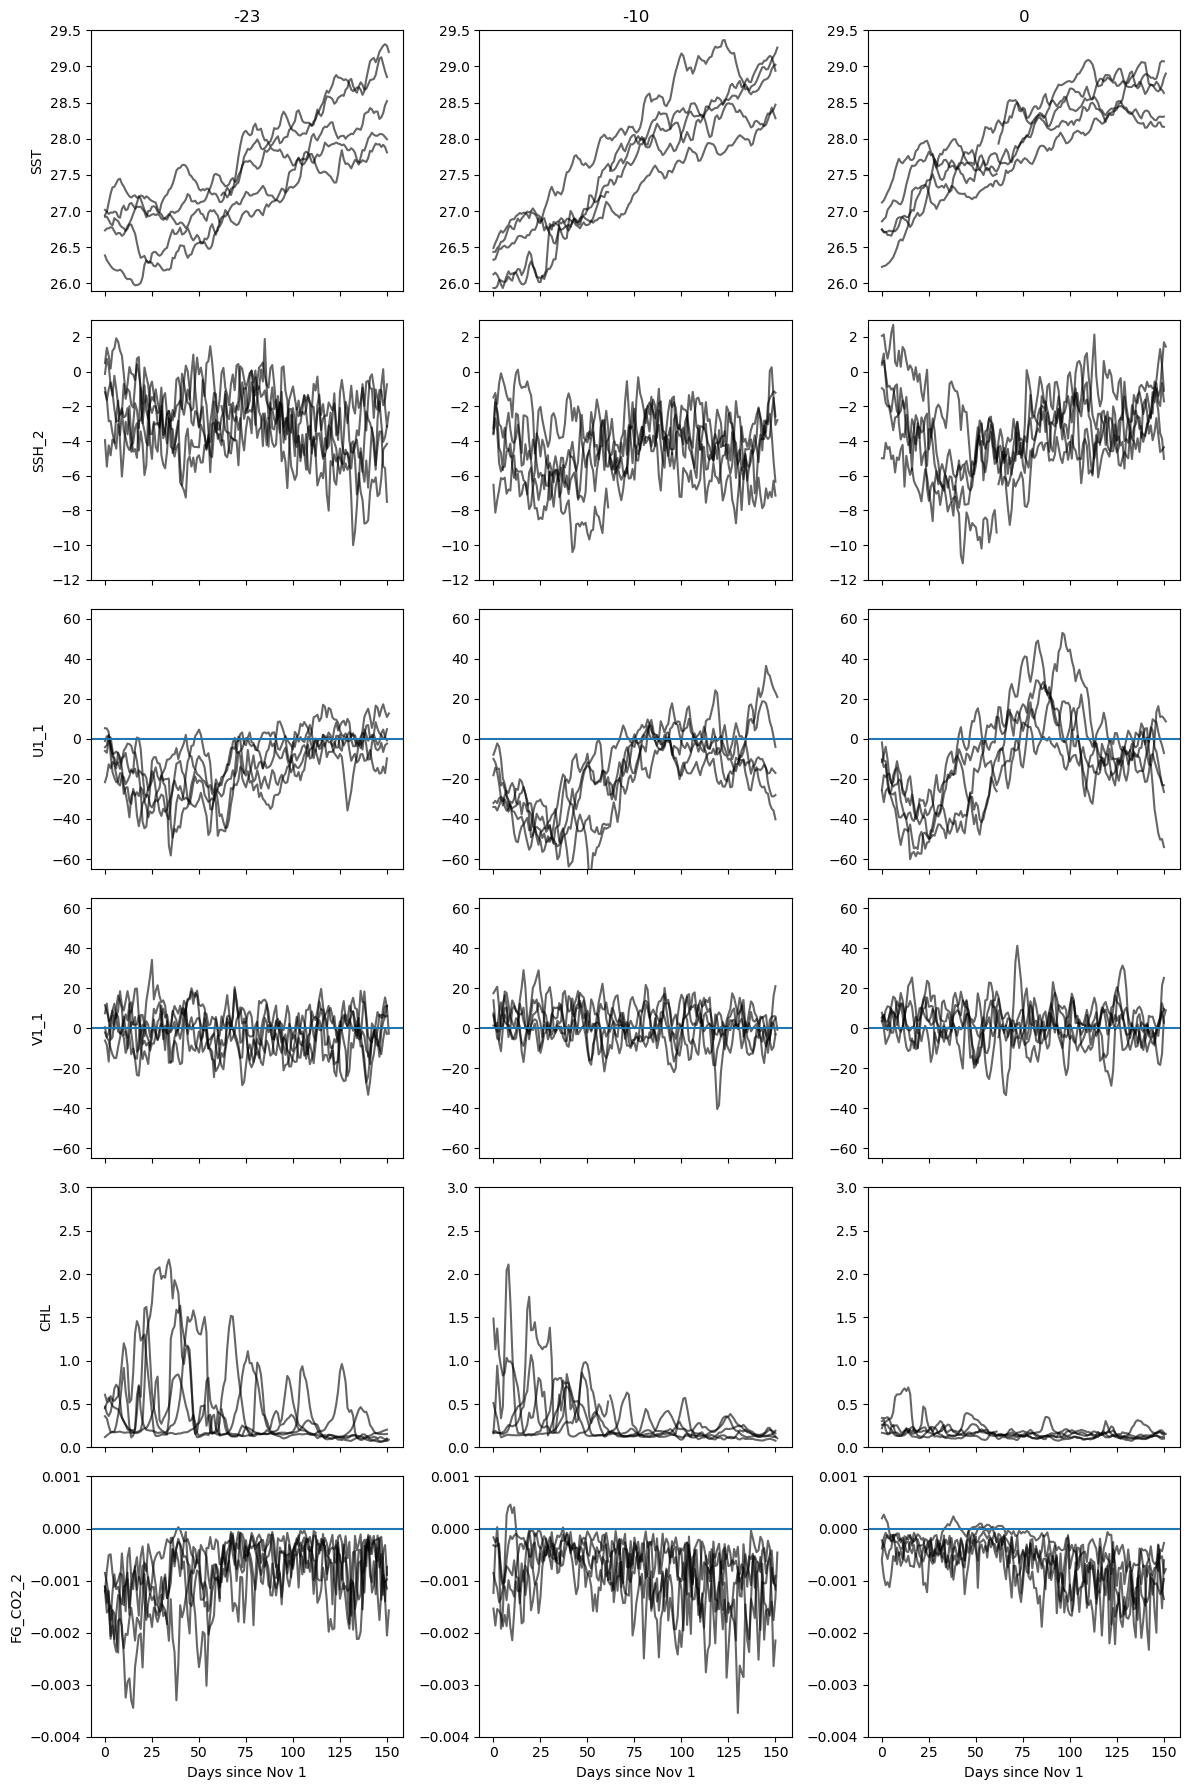

In [24]:
import matplotlib.pyplot as plt
import pandas as pd

nvars = len(variables)
nlon = len(glider_ilon)
vmins=[25.9, -12, -65,-65, 0,-0.004]
vmaxs=[29.5, 3, 65, 65,  3, 0.001]

fig, axes = plt.subplots(nvars, nlon, figsize=(12, 3*nvars), sharex=True)

for v, var in enumerate(variables):
    print(v)
    # global y-limits per variable
    # vmin_ = datasets[v][var].sel(nlat=41).min()
    # vmax_ = datasets[v][var].sel(nlat=41).max()

    for ii in range(nlon):
        ax = axes[v, ii] if nvars > 1 else axes[ii]

        d_plot = datasets[v].sel(nlat=41).sel(nlon=glider_ilon[ii])

        # fix time
        time = pd.to_datetime([str(t) for t in d_plot.time.values])
        d_plot["time"] = time

        for year in range(2016, 2022):
            start = f"{year}-11-01"
            end   = f"{year+1}-03-31"

            d_season = d_plot.sel(time=slice(start, end))

            t = pd.to_datetime(d_season.time.values)
            season_day = (t - pd.Timestamp(f"{year}-11-01")).days

            ax.plot(season_day, d_season[var], c='k', alpha=0.6)

        # titles (top row only)
        if v == 0:
            ax.set_title(round(lon_new[glider_ilon[ii]]))

        # y labels (left column only)
        if ii == 0:
            ax.set_ylabel(var)
        # else:
            # ax.set_yticks([])

        if v == 2:
            ax.axhline(0)
        if v == 3:
            ax.axhline(0)
        if v == 5:
            ax.axhline(0)

        ax.set_ylim(vmins[v], vmaxs[v])

        # x labels (bottom row only)
        if v == nvars - 1:
            ax.set_xlabel("Days since Nov 1")

plt.tight_layout()
plt.show()

## map glider on hovmoler

In [ ]:
speed = 4/3 #km/h
speed_day= speed*24 # km / day
print(speed_day) 

def hovmoller_track(speed=24, max_dist=100):
    n = len(datetime)
    distance = np.zeros(n)
    direction = 1

    for i in range(1, n):
        distance[i] = distance[i-1] + direction * speed

        if distance[i] >= max_dist:
            distance[i] = max_dist
            direction = -1
        elif distance[i] <= -max_dist:
            distance[i] = -max_dist
            direction = 1

    return xr.DataArray(distance, coords={'time': datetime}, dims='time')

In [161]:
i=0
data_plot=datasets[i].sel(nlon=glider_ilon[0]).sel(nlat=slice(18,63))[variables[i]]
data_plot = np.abs(data_plot.diff('nlat'))/10 # deg per km
# distance in km for each nlat point
dist_km = data_plot['TLAT'] * 100
# attach it as a coordinate on the nlat dimension
SST_dist = data_plot.assign_coords(dist=('nlat', dist_km.data)).swap_dims({'nlat': 'dist'})
SST_dist['time']=datetime

In [162]:
track_200 = hovmoller_track(speed=speed_day, max_dist=200)
track_100 = hovmoller_track(speed=speed_day, max_dist=100)
track_50 = hovmoller_track(speed=speed_day, max_dist=50)

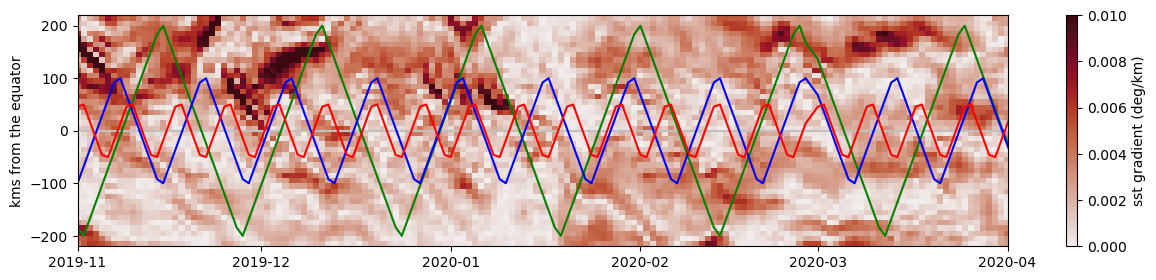

In [168]:
plt.figure(figsize=(15,3))
plt.pcolormesh(datetime, data_plot.TLAT.values*100, (data_plot.T),  cmap=cmo.amp, vmin=0, vmax=0.01)
plt.axhline(0, c='silver')
plt.colorbar(label='sst gradient (deg/km)')
plt.ylabel('kms from the equator')
plt.xlim(pd.to_datetime('2019-11-01'),pd.to_datetime('2020-04-01'))
plt.plot(datetime, hovmoller_track(speed_day, 200), c='green')#, s=10)
plt.plot(datetime, hovmoller_track(speed_day, 100), c='blue')#, s=10)
plt.plot(datetime, hovmoller_track(speed_day, 50), c='red')#, s=10)



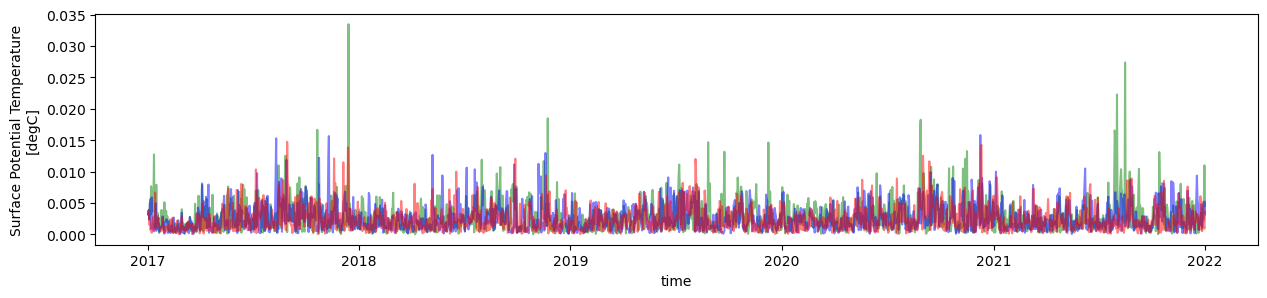

In [164]:
plt.figure(figsize=(15,3))
# interpolate on glider sampling
SST_dist.interp(dist=track_200).plot(color='green', alpha=0.5)
SST_dist.interp(dist=track_100).plot(color='blue', alpha=0.5)
SST_dist.interp(dist=track_50).plot(color='red', alpha=0.5)


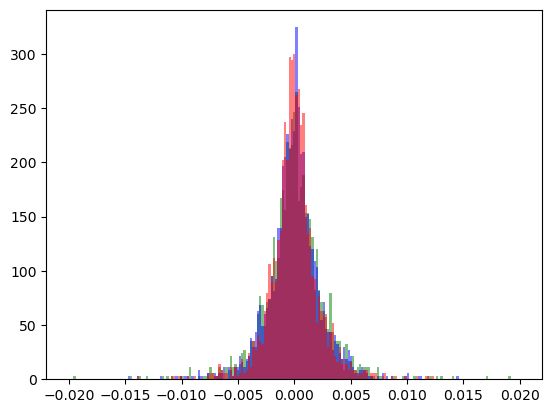

In [167]:
_=plt.hist(SST_dist.interp(dist=track_200).diff('time'), bins=np.linspace(-0.02,0.02, 200), density=True, color='green', alpha=0.5)
_=plt.hist(SST_dist.interp(dist=track_100).diff('time'), bins=np.linspace(-0.02,0.02, 200), density=True, color='blue', alpha=0.5)
_=plt.hist(SST_dist.interp(dist=track_50).diff('time'), bins=np.linspace(-0.02,0.02, 200), density=True, color='red', alpha=0.5)